In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("docs/figures", exist_ok=True)
sns.set_theme(style="whitegrid")

print("All libraries loaded successfully")

All libraries loaded successfully


In [6]:
import pandas as pd
import os

# Load gold layer — it is a partitioned folder not a single file
gold = pd.read_parquet("C:/Users/abeer/Desktop/Big Data/gold")

print(f"Total records: {len(gold):,}")
print(f"Years: {sorted(gold['year'].unique())}")
print(f"Price zones: {sorted(gold['price_zone'].unique())}")
print(f"Columns: {list(gold.columns)}")
print(f"Avg temperature: {gold['avg_temp'].mean():.2f} C")
print(f"Avg spot price: {gold['avg_spot_price'].mean():.2f} SEK/MWh")

Total records: 210,316
Years: [2019, 2020, 2021, 2022, 2023, 2024]
Price zones: ['SE1', 'SE2', 'SE3', 'SE4']
Columns: ['price_zone', 'date', 'hour', 'avg_temp', 'min_temp', 'max_temp', 'station_count', 'avg_spot_price', 'rolling_24h_avg_temp', 'monthly_price_rank', 'year', 'month']
Avg temperature: 5.15 C
Avg spot price: 400.02 SEK/MWh


In [7]:
# Real correlation numbers for your report
corr_temp_price = gold['avg_temp'].corr(gold['avg_spot_price'])
corr_rolling_price = gold['rolling_24h_avg_temp'].corr(gold['avg_spot_price'])

print("=" * 50)
print("KEY NUMBERS FOR YOUR REPORT")
print("=" * 50)
print(f"Temperature vs Spot Price:       {corr_temp_price:.4f}")
print(f"Rolling 24h Temp vs Spot Price:  {corr_rolling_price:.4f}")
print(f"Total records:                   {len(gold):,}")
print(f"Years covered:                   2019 to 2024")
print(f"Max spot price:                  {gold['avg_spot_price'].max():.2f} SEK/MWh")
print(f"Min temperature recorded:        {gold['avg_temp'].min():.2f} C")
print("=" * 50)

KEY NUMBERS FOR YOUR REPORT
Temperature vs Spot Price:       -0.5962
Rolling 24h Temp vs Spot Price:  -0.6467
Total records:                   210,316
Years covered:                   2019 to 2024
Max spot price:                  1075.53 SEK/MWh
Min temperature recorded:        -33.69 C


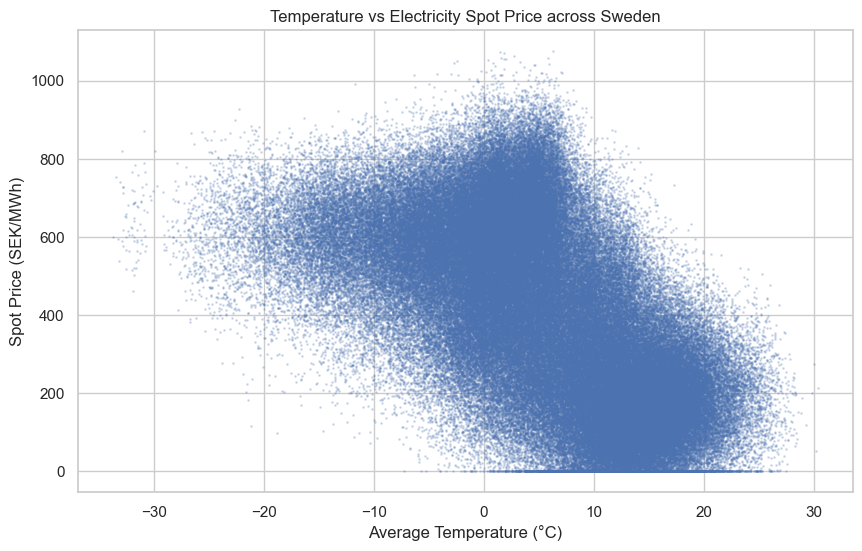

Chart 1 saved


In [8]:
# Chart 1: Temperature vs Consumption
plt.figure(figsize=(10, 6))
plt.scatter(gold['avg_temp'], gold['avg_spot_price'], alpha=0.2, s=1)
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Spot Price (SEK/MWh)")
plt.title("Temperature vs Electricity Spot Price across Sweden")
plt.savefig("docs/figures/chart1_temp_vs_consumption.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

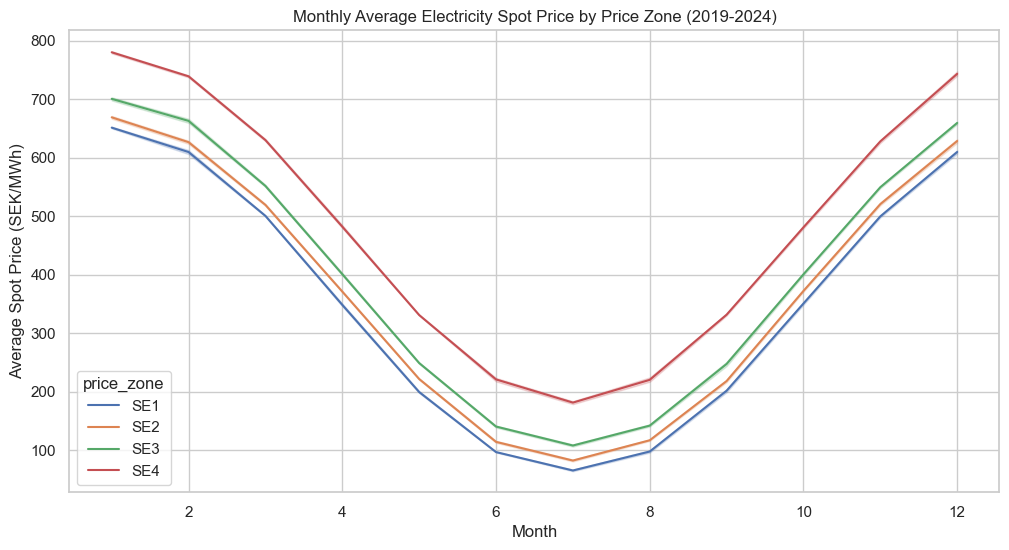

Chart 2 saved


In [10]:
# Chart 2: Monthly avg spot price by price zone
monthly = gold.groupby(['year','month','price_zone'], observed=True)['avg_spot_price'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x='month', y='avg_spot_price', hue='price_zone')
plt.xlabel("Month")
plt.ylabel("Average Spot Price (SEK/MWh)")
plt.title("Monthly Average Electricity Spot Price by Price Zone (2019-2024)")
plt.savefig("docs/figures/chart2_monthly_by_zone.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

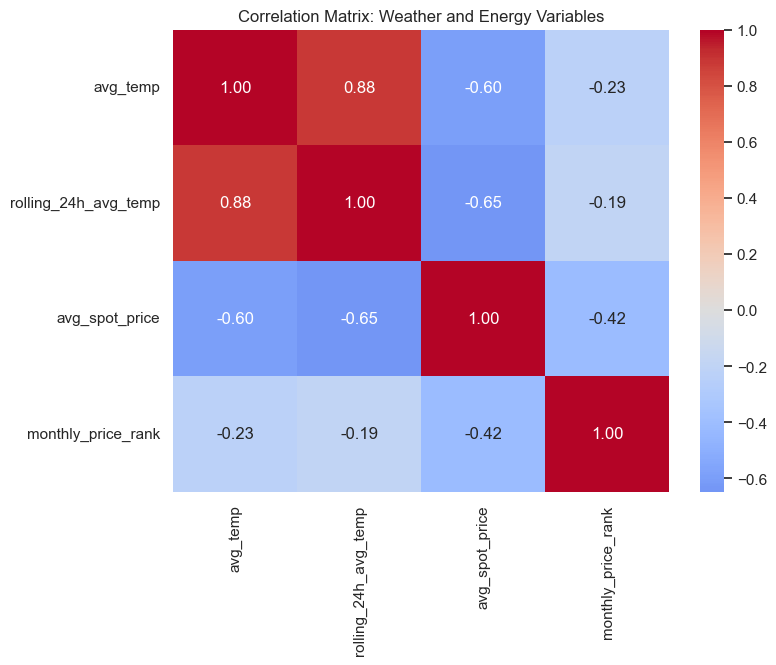

Chart 3 saved


In [11]:
# Chart 3: Correlation heatmap
cols = ['avg_temp', 'rolling_24h_avg_temp', 'avg_spot_price', 'monthly_price_rank']
plt.figure(figsize=(8, 6))
sns.heatmap(gold[cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title("Correlation Matrix: Weather and Energy Variables")
plt.savefig("docs/figures/chart3_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

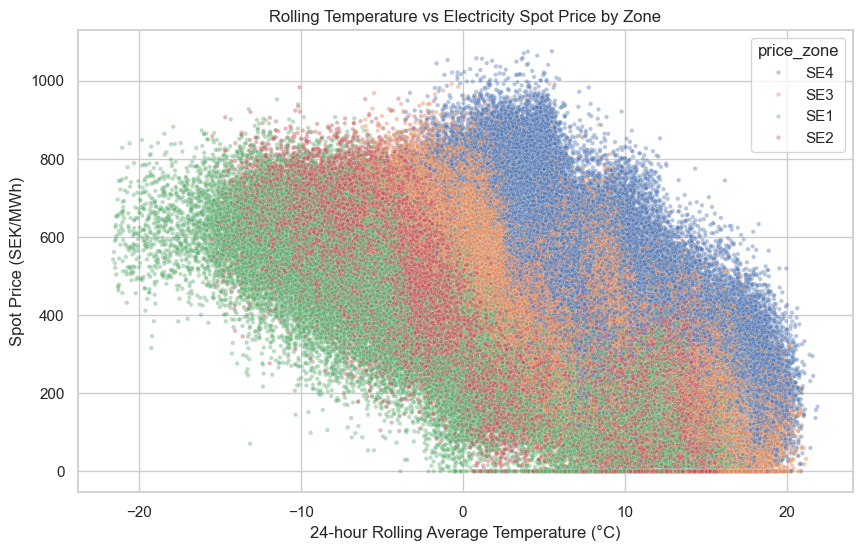

Chart 4 saved


In [14]:
# Chart 4: Rolling temperature vs spot price
plt.figure(figsize=(10, 6))
sns.scatterplot(data=gold, x='rolling_24h_avg_temp',
                y='avg_spot_price', hue='price_zone',
                alpha=0.4, s=10)
plt.xlabel("24-hour Rolling Average Temperature (°C)")
plt.ylabel("Spot Price (SEK/MWh)")
plt.title("Rolling Temperature vs Electricity Spot Price by Zone")
plt.savefig("docs/figures/chart4_rolling_vs_price.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")
